# 🎵 Benchmark de LLMs para Geração de Código em Teoria Musical
### Versão com modelos locais via Ollama: Qwen3 vs Gemma3

**Metodologia de Execução do Experimento**

Este notebook implementa um experimento controlado com abordagem mista (quantitativa + qualitativa) para avaliar a capacidade de modelos LLM em gerar código Python para problemas de teoria musical, seguindo a mesma metodologia do artigo original — agora com inferência 100% local via [Ollama](https://ollama.com).

### Variáveis do Experimento
- **Independentes:** Modelo de LLM (2 níveis: `qwen3:8b`, `gemma3:4b`) × Estratégia de Prompt (2 níveis: zero-shot, few-shot) × Complexidade do Problema (3 níveis: básico, intermediário, avançado)
- **Dependente:** Correção Funcional = percentual de testes unitários `pytest` aprovados (0–100%)
- **Total:** 2 × 2 × 10 = **40 gerações de código**, cada uma avaliada com 5–8 testes unitários (**66 execuções de teste no total**)
- **Análise estatística:** Teste de Wilcoxon (pareado, não-paramétrico, adequado para N pequeno) comparando os modelos e as estratégias

### Pré-requisitos
1. [Ollama](https://ollama.com) instalado e em execução (`ollama serve`)
2. Modelos baixados localmente:
   ```bash
   ollama pull qwen3:8b
   ollama pull gemma3:4b
   ```
3. Arquivo `problemas.json` na mesma pasta deste notebook


## 1. Instalação e Importação de Dependências

In [2]:
# !pip install requests pandas numpy scipy matplotlib seaborn pytest -q

In [3]:
import os
import sys
import re
import json
import csv
import shutil
import subprocess
import requests
from pathlib import Path
from itertools import product
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
print("Dependências carregadas com sucesso.")

Dependências carregadas com sucesso.


## 2. Configuração do Experimento

Define os modelos ativos (via Ollama), estratégias de prompt e caminhos do projeto.


In [4]:
BASE_DIR = Path.cwd()
GENERATED_DIR = BASE_DIR / "generated"
TESTS_DIR = BASE_DIR / "tests"
RESULTS_FILE = BASE_DIR / "results.csv"
RESULTS_JSON = BASE_DIR / "results.json"

GENERATED_DIR.mkdir(exist_ok=True)
TESTS_DIR.mkdir(exist_ok=True)

OLLAMA_URL = "http://localhost:11434/api/chat"
OLLAMA_TAGS_URL = "http://localhost:11434/api/tags"

CONFIG = {
    "ollama_models": {
        "qwen3.6": "qwen3.6:latest",
        "gemma4": "gemma4:latest",
    },
    "temperature": 0.2,
    # Modelos com "thinking mode" (ex.: qwen3.6) gastam tokens pensando antes
    # de responder. Se num_predict for baixo, o raciocínio consome todo o
    # orçamento e o campo "content" pode vir vazio mesmo com status 200.
    "max_tokens": 4000,
    "timeout_segundos": 30,
    # Geração com thinking mode é bem mais lenta (pode passar de 1-2 min
    # só de raciocínio antes do código). Timeout maior evita falsos timeouts.
    "timeout_geracao": 300,
}

# Edite esta lista para ativar/desativar modelos do experimento sem tocar no resto do código
ACTIVE_MODELS = list(CONFIG["ollama_models"].keys())
STRATEGIES = ["zero-shot", "few-shot"]

print("Modelos ativos:", ACTIVE_MODELS)
print("Estratégias:", STRATEGIES)

Modelos ativos: ['qwen3.6', 'gemma4']
Estratégias: ['zero-shot', 'few-shot']


## 3. Verificação de Conectividade com Ollama

Confirma que o serviço Ollama está rodando e que os modelos configurados estão de fato baixados, antes de iniciar o experimento (evita falhas no meio das 40 gerações).


In [5]:
def check_ollama():
    try:
        resp = requests.get(OLLAMA_TAGS_URL, timeout=5)
        resp.raise_for_status()
    except requests.RequestException as exc:
        print(f"❌ Não foi possível conectar ao Ollama em {OLLAMA_TAGS_URL}")
        print(f"   Erro: {exc}")
        print("   Verifique se o serviço está rodando com `ollama serve`.")
        return False

    modelos_instalados = {m["name"] for m in resp.json().get("models", [])}
    print("Modelos instalados no Ollama:", sorted(modelos_instalados))

    tudo_ok = True
    for chave, tag in CONFIG["ollama_models"].items():
        if chave not in ACTIVE_MODELS:
            continue
        if tag in modelos_instalados:
            print(f"  ✅ {chave} ({tag}) — disponível")
        else:
            print(f"  ⚠️  {chave} ({tag}) — NÃO encontrado. Rode: ollama pull {tag}")
            tudo_ok = False

    return tudo_ok


ollama_ok = check_ollama()
if not ollama_ok:
    print("\n⚠️  Resolva os avisos acima antes de rodar o experimento completo.")

Modelos instalados no Ollama: ['gemma4:latest', 'qwen3.6:latest']
  ✅ qwen3.6 (qwen3.6:latest) — disponível
  ✅ gemma4 (gemma4:latest) — disponível


## 4. Carregamento dos Problemas

Carrega os 10 problemas de teoria musical (3 níveis de dificuldade) a partir de `problemas.json`.


In [6]:
def carregar_problemas():
    caminho = BASE_DIR / "problemas.json"
    if not caminho.exists():
        raise FileNotFoundError(
            "problemas.json não encontrado. Coloque o arquivo na mesma pasta deste notebook."
        )
    with open(caminho, "r", encoding="utf-8") as arquivo:
        return json.load(arquivo)


PROBLEMAS = carregar_problemas()

df_problemas = pd.DataFrame(PROBLEMAS)
print(f"Total de problemas carregados: {len(PROBLEMAS)}")
df_problemas[["id", "titulo", "nivel"]]

Total de problemas carregados: 10


,id,titulo,nivel
0,P01,Calcular intervalo entre notas,basico
1,P02,Validar escala maior,basico
2,P03,Converter cifra para semitom,basico
3,P04,Classificar tríade,intermediario
4,P05,Gerar campo harmônico maior,intermediario
5,P06,Detectar inversão de acorde,intermediario
6,P07,Validar progressão harmônica,intermediario
7,P08,Classificar tétrade,avancado
8,P09,Verificar condução de vozes,avancado
9,P10,Detectar modulação tonal,avancado


## 5. Código de Referência (Ground Truth)

Implementações de referência para cada um dos 10 problemas, validadas com 100% de aprovação nos respectivos testes. Servem como gabarito e também permitem gerar exemplos para o prompt few-shot.


In [7]:
GABARITOS = {
    "P01": '''CROMATICA = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]


def calcular_intervalo(nota1: str, nota2: str) -> int:
    i1 = CROMATICA.index(nota1)
    i2 = CROMATICA.index(nota2)
    return (i2 - i1) % 12
''',

    "P02": '''CROMATICA = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
PADRAO_MAIOR = [2, 2, 1, 2, 2, 2, 1]


def validar_escala_maior(notas: list[str]) -> bool:
    if len(notas) != 8:
        return False
    for i in range(7):
        idx_atual = CROMATICA.index(notas[i])
        idx_proximo = CROMATICA.index(notas[i + 1])
        intervalo = (idx_proximo - idx_atual) % 12
        if intervalo != PADRAO_MAIOR[i]:
            return False
    return True
''',

    "P03": '''CROMATICA = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]


def cifra_para_semitom(nota: str) -> int:
    return CROMATICA.index(nota)
''',

    "P04": '''CROMATICA = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]


def _intervalo(n1, n2):
    return (CROMATICA.index(n2) - CROMATICA.index(n1)) % 12


def classificar_triade(notas: list[str]) -> str:
    fundamental, terca, quinta = notas
    i_terca = _intervalo(fundamental, terca)
    i_quinta = _intervalo(fundamental, quinta)
    if i_terca == 4 and i_quinta == 7:
        return "maior"
    if i_terca == 3 and i_quinta == 7:
        return "menor"
    if i_terca == 3 and i_quinta == 6:
        return "diminuta"
    if i_terca == 4 and i_quinta == 8:
        return "aumentada"
    return "desconhecida"
''',

    "P05": '''CROMATICA = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
PADRAO_MAIOR = [0, 2, 4, 5, 7, 9, 11]
QUALIDADES = ["", "m", "m", "", "", "m", "dim"]


def gerar_campo_harmonico_maior(tonalidade: str) -> list[str]:
    idx_tonica = CROMATICA.index(tonalidade)
    campo = []
    for semitons, qualidade in zip(PADRAO_MAIOR, QUALIDADES):
        idx_nota = (idx_tonica + semitons) % 12
        campo.append(CROMATICA[idx_nota] + qualidade)
    return campo
''',

    "P06": '''CROMATICA = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]


def _intervalo(n1, n2):
    return (CROMATICA.index(n2) - CROMATICA.index(n1)) % 12


def _eh_triade_valida(fundamental, terca, quinta):
    i_terca = _intervalo(fundamental, terca)
    i_quinta = _intervalo(fundamental, quinta)
    return (i_terca, i_quinta) in [(4, 7), (3, 7), (3, 6), (4, 8)]


def detectar_inversao(notas: list[str]) -> str:
    baixo = notas[0]
    n0, n1, n2 = notas
    rotacoes = [(n0, n1, n2), (n1, n2, n0), (n2, n0, n1)]
    for fundamental, terca, quinta in rotacoes:
        if _eh_triade_valida(fundamental, terca, quinta):
            if baixo == fundamental:
                return "estado fundamental"
            if baixo == terca:
                return "primeira inversao"
            if baixo == quinta:
                return "segunda inversao"
    return "desconhecida"
''',

    "P07": '''def validar_progressao(graus: list[str]) -> bool:
    if not graus or graus[-1] != "I":
        return False
    return "IV" in graus[:-1] or "V" in graus[:-1]
''',

    "P08": '''CROMATICA = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]


def _intervalo(n1, n2):
    return (CROMATICA.index(n2) - CROMATICA.index(n1)) % 12


def classificar_tetrade(notas: list[str]) -> str:
    fundamental, terca, quinta, setima = notas
    i_terca = _intervalo(fundamental, terca)
    i_quinta = _intervalo(fundamental, quinta)
    i_setima = _intervalo(fundamental, setima)
    if i_terca == 4 and i_quinta == 7 and i_setima == 11:
        return "maior7"
    if i_terca == 4 and i_quinta == 7 and i_setima == 10:
        return "dominante7"
    if i_terca == 3 and i_quinta == 7 and i_setima == 10:
        return "menor7"
    if i_terca == 3 and i_quinta == 6 and i_setima == 10:
        return "meio_diminuto"
    return "desconhecida"
''',

    "P09": '''def verificar_conducao_vozes(acorde1: list[int], acorde2: list[int]) -> bool:
    for v1, v2 in zip(acorde1, acorde2):
        if abs(v2 - v1) > 5:
            return False
    return True
''',

    "P10": '''def detectar_modulacao(tonalidades: list[str]) -> bool:
    if len(tonalidades) < 2:
        return False
    primeira = tonalidades[0]
    return any(t != primeira for t in tonalidades[1:])
''',
}

print(f"Gabaritos carregados para {len(GABARITOS)} problemas.")

Gabaritos carregados para 10 problemas.


## 6. Testes Unitários

Os 10 arquivos de teste (`pytest`) são escritos em disco em `tests/`. Cada problema possui de 5 a 8 testes, categorizados em *happy path*, *edge case*, *invalid input* e *complex* — 66 testes no total.


In [8]:
TESTES = {
    "test_p01.py": '''from solution import calcular_intervalo


def test_intervalo_c_para_e():
    assert calcular_intervalo("C", "E") == 4

def test_intervalo_c_para_g():
    assert calcular_intervalo("C", "G") == 7

def test_intervalo_iguais():
    assert calcular_intervalo("D", "D") == 0

def test_intervalo_b_para_c():
    assert calcular_intervalo("B", "C") == 1

def test_intervalo_g_para_c():
    assert calcular_intervalo("G", "C") == 5

def test_intervalo_descendente_circular():
    assert calcular_intervalo("A", "C") == 3

def test_intervalo_sustenidos():
    assert calcular_intervalo("F#", "A#") == 4

def test_intervalo_volta_completa():
    assert calcular_intervalo("C", "B") == 11
''',

    "test_p02.py": '''from solution import validar_escala_maior


def test_escala_c_maior_valida():
    assert validar_escala_maior(["C", "D", "E", "F", "G", "A", "B", "C"]) is True

def test_escala_g_maior_valida():
    assert validar_escala_maior(["G", "A", "B", "C", "D", "E", "F#", "G"]) is True

def test_escala_tamanho_invalido():
    assert validar_escala_maior(["C", "D", "E", "F", "G", "A", "B"]) is False

def test_escala_com_nove_notas():
    assert validar_escala_maior(["C", "D", "E", "F", "G", "A", "B", "C", "D"]) is False

def test_escala_menor_nao_valida():
    assert validar_escala_maior(["A", "B", "C", "D", "E", "F", "G", "A"]) is False

def test_escala_com_sustenidos_multiplos():
    assert validar_escala_maior(["D", "E", "F#", "G", "A", "B", "C#", "D"]) is True

def test_escala_ordem_errada():
    assert validar_escala_maior(["C", "E", "D", "F", "G", "A", "B", "C"]) is False
''',

    "test_p03.py": '''from solution import cifra_para_semitom


def test_cifra_c():
    assert cifra_para_semitom("C") == 0

def test_cifra_g():
    assert cifra_para_semitom("G") == 7

def test_cifra_b():
    assert cifra_para_semitom("B") == 11

def test_cifra_sustenido_a():
    assert cifra_para_semitom("A#") == 10

def test_cifra_sustenido_c():
    assert cifra_para_semitom("C#") == 1

def test_cifra_todas_sequencial():
    notas = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
    valores = [cifra_para_semitom(n) for n in notas]
    assert valores == list(range(12))
''',

    "test_p04.py": '''from solution import classificar_triade


def test_triade_maior():
    assert classificar_triade(["C", "E", "G"]) == "maior"

def test_triade_menor():
    assert classificar_triade(["C", "D#", "G"]) == "menor"

def test_triade_diminuta():
    assert classificar_triade(["C", "D#", "F#"]) == "diminuta"

def test_triade_aumentada():
    assert classificar_triade(["C", "E", "G#"]) == "aumentada"

def test_triade_invalida():
    assert classificar_triade(["C", "D", "F#"]) == "desconhecida"

def test_triade_maior_outra_tonica():
    assert classificar_triade(["G", "B", "D"]) == "maior"

def test_triade_menor_com_sustenido():
    assert classificar_triade(["F#", "A", "C#"]) == "menor"
''',

    "test_p05.py": '''from solution import gerar_campo_harmonico_maior


def test_campo_c_maior():
    esperado = ["C", "Dm", "Em", "F", "G", "Am", "Bdim"]
    assert gerar_campo_harmonico_maior("C") == esperado

def test_campo_g_maior():
    esperado = ["G", "Am", "Bm", "C", "D", "Em", "F#dim"]
    assert gerar_campo_harmonico_maior("G") == esperado

def test_campo_comeca_com_sustenido():
    campo = gerar_campo_harmonico_maior("F#")
    assert campo[0] == "F#"
    assert len(campo) == 7

def test_campo_b_maior_apenas_sustenidos():
    campo = gerar_campo_harmonico_maior("B")
    assert all("b" not in acorde for acorde in campo)
    assert campo[0] == "B"

def test_campo_tamanho_sempre_sete():
    for tonica in ["C", "D", "E", "F", "G", "A", "B"]:
        assert len(gerar_campo_harmonico_maior(tonica)) == 7
''',

    "test_p06.py": '''from solution import detectar_inversao


def test_estado_fundamental_maior():
    assert detectar_inversao(["C", "E", "G"]) == "estado fundamental"

def test_estado_fundamental_menor():
    assert detectar_inversao(["A", "C", "E"]) == "estado fundamental"

def test_primeira_inversao():
    assert detectar_inversao(["E", "G", "C"]) == "primeira inversao"

def test_segunda_inversao():
    assert detectar_inversao(["G", "C", "E"]) == "segunda inversao"

def test_primeira_inversao_menor():
    assert detectar_inversao(["C", "E", "A"]) == "primeira inversao"

def test_segunda_inversao_outra_triade():
    assert detectar_inversao(["D", "G", "B"]) == "segunda inversao"
''',

    "test_p07.py": '''from solution import validar_progressao


def test_progressao_valida_com_v():
    assert validar_progressao(["I", "IV", "V", "I"]) is True

def test_progressao_valida_com_iv():
    assert validar_progressao(["I", "IV", "I"]) is True

def test_progressao_sem_resolucao():
    assert validar_progressao(["I", "IV", "V"]) is False

def test_progressao_sem_iv_ou_v():
    assert validar_progressao(["I", "vi", "I"]) is False

def test_progressao_vazia():
    assert validar_progressao([]) is False

def test_progressao_longa_valida():
    assert validar_progressao(["I", "vi", "IV", "V", "vi", "IV", "V", "I"]) is True

def test_progressao_termina_errado():
    assert validar_progressao(["I", "IV", "V", "vi"]) is False
''',

    "test_p08.py": '''from solution import classificar_tetrade


def test_tetrade_maior7():
    assert classificar_tetrade(["C", "E", "G", "B"]) == "maior7"

def test_tetrade_dominante7():
    assert classificar_tetrade(["C", "E", "G", "A#"]) == "dominante7"

def test_tetrade_menor7():
    assert classificar_tetrade(["C", "D#", "G", "A#"]) == "menor7"

def test_tetrade_meio_diminuto():
    assert classificar_tetrade(["C", "D#", "F#", "A#"]) == "meio_diminuto"

def test_tetrade_invalida():
    assert classificar_tetrade(["C", "D", "F#", "A"]) == "desconhecida"

def test_tetrade_maior7_outra_tonica():
    assert classificar_tetrade(["G", "B", "D", "F#"]) == "maior7"

def test_tetrade_dominante7_outra_tonica():
    assert classificar_tetrade(["G", "B", "D", "F"]) == "dominante7"
''',

    "test_p09.py": '''from solution import verificar_conducao_vozes


def test_conducao_suave():
    assert verificar_conducao_vozes([60, 64, 67, 71], [60, 65, 67, 72]) is True

def test_conducao_identica():
    assert verificar_conducao_vozes([60, 64, 67, 71], [60, 64, 67, 71]) is True

def test_conducao_exatamente_no_limite():
    assert verificar_conducao_vozes([60, 64, 67, 71], [60, 69, 67, 71]) is True

def test_conducao_excede_limite():
    assert verificar_conducao_vozes([60, 64, 67, 71], [60, 70, 67, 71]) is False

def test_conducao_uma_voz_grande_salto():
    assert verificar_conducao_vozes([48, 52, 55, 59], [48, 52, 55, 71]) is False

def test_conducao_movimento_descendente():
    assert verificar_conducao_vozes([60, 64, 67, 71], [60, 60, 67, 71]) is True
''',

    "test_p10.py": '''from solution import detectar_modulacao


def test_modulacao_detectada():
    assert detectar_modulacao(["C", "C", "G", "G"]) is True

def test_sem_modulacao():
    assert detectar_modulacao(["C", "C", "C", "C"]) is False

def test_modulacao_lista_curta():
    assert detectar_modulacao(["C"]) is False

def test_modulacao_lista_vazia():
    assert detectar_modulacao([]) is False

def test_modulacao_multiplas_tonalidades():
    assert detectar_modulacao(["C", "G", "D", "A"]) is True

def test_modulacao_volta_a_original():
    assert detectar_modulacao(["C", "G", "C"]) is True
''',
}

for nome_arquivo, conteudo in TESTES.items():
    with open(TESTS_DIR / nome_arquivo, "w", encoding="utf-8") as f:
        f.write(conteudo)

print(f"{len(TESTES)} arquivos de teste escritos em {TESTS_DIR}")

10 arquivos de teste escritos em c:\Users\jgmda\Documents\GitHub\Doutorado\EsofInteligente\tests


In [9]:
# Sanidade: valida que TODOS os gabaritos passam em 100% dos próprios testes
# (garante que a métrica de correção funcional é confiável antes do experimento)

def validar_gabaritos():
    total_ok = 0
    for problema in PROBLEMAS:
        pid = problema["id"]
        titulo = problema["titulo"]
        nome_teste = problema["arquivo_teste"]

        temp_dir = BASE_DIR / "_sanity_check"
        if temp_dir.exists():
            shutil.rmtree(temp_dir)
        temp_dir.mkdir()

        with open(temp_dir / "solution.py", "w", encoding="utf-8") as f:
            f.write(GABARITOS[pid])
        shutil.copy(TESTS_DIR / nome_teste, temp_dir / nome_teste)

        resultado = subprocess.run(
            [sys.executable, "-m", "pytest", nome_teste, "-q", "--color=no"],
            cwd=temp_dir, capture_output=True, text=True,
            encoding="utf-8", errors="replace", timeout=30
        )
        ok = resultado.returncode == 0
        total_ok += int(ok)
        status = "✅" if ok else "❌"
        print(f"  {status} {pid} — {titulo}")

        shutil.rmtree(temp_dir)

    print(f"\n{total_ok}/{len(PROBLEMAS)} gabaritos validados com sucesso.")
    return total_ok == len(PROBLEMAS)


gabaritos_ok = validar_gabaritos()
assert gabaritos_ok, "Algum gabarito não passou nos próprios testes — corrija antes de continuar."

  ✅ P01 — Calcular intervalo entre notas
  ✅ P02 — Validar escala maior
  ✅ P03 — Converter cifra para semitom
  ✅ P04 — Classificar tríade
  ✅ P05 — Gerar campo harmônico maior
  ✅ P06 — Detectar inversão de acorde
  ✅ P07 — Validar progressão harmônica
  ✅ P08 — Classificar tétrade
  ✅ P09 — Verificar condução de vozes
  ✅ P10 — Detectar modulação tonal

10/10 gabaritos validados com sucesso.


## 7. Construção dos Prompts (Zero-shot e Few-shot)

- **Zero-shot:** apenas a descrição e a assinatura da função.
- **Few-shot:** inclui um exemplo completo (problema + solução) de outro problema do mesmo nível de dificuldade antes da tarefa real, para dar contexto de estilo e formato esperado.


In [10]:
def montar_prompt_zero_shot(problema: dict) -> str:
    return f'''Você é um programador Python especialista em teoria musical.

Implemente a função descrita abaixo. Responda APENAS com o código Python, sem explicações, sem markdown, sem comentários adicionais.

Título: {problema["titulo"]}
Descrição: {problema["descricao"]}
Assinatura obrigatória: {problema["assinatura"]}
'''


def _escolher_exemplo_few_shot(problema: dict) -> dict:
    """Escolhe outro problema do mesmo nível para servir de exemplo few-shot."""
    candidatos = [p for p in PROBLEMAS if p["nivel"] == problema["nivel"] and p["id"] != problema["id"]]
    if not candidatos:
        candidatos = [p for p in PROBLEMAS if p["id"] != problema["id"]]
    return candidatos[0]


def montar_prompt_few_shot(problema: dict) -> str:
    exemplo = _escolher_exemplo_few_shot(problema)
    codigo_exemplo = GABARITOS[exemplo["id"]].strip()

    return f'''Você é um programador Python especialista em teoria musical.

Implemente a função descrita, seguindo o mesmo estilo do exemplo abaixo. Responda APENAS com o código Python, sem explicações, sem markdown, sem comentários adicionais.

### Exemplo
Título: {exemplo["titulo"]}
Descrição: {exemplo["descricao"]}
Assinatura: {exemplo["assinatura"]}

Solução:
{codigo_exemplo}

### Tarefa
Título: {problema["titulo"]}
Descrição: {problema["descricao"]}
Assinatura obrigatória: {problema["assinatura"]}
'''


def montar_prompt(problema: dict, estrategia: str) -> str:
    if estrategia == "zero-shot":
        return montar_prompt_zero_shot(problema)
    if estrategia == "few-shot":
        return montar_prompt_few_shot(problema)
    raise ValueError(f"Estratégia desconhecida: {estrategia}")


# Exemplo de prompt gerado
print(montar_prompt(PROBLEMAS[0], "zero-shot"))

Você é um programador Python especialista em teoria musical.

Implemente a função descrita abaixo. Responda APENAS com o código Python, sem explicações, sem markdown, sem comentários adicionais.

Título: Calcular intervalo entre notas
Descrição: Crie uma função que receba duas notas musicais e retorne a distância ascendente em semitons entre elas. Considere a escala cromática: C, C#, D, D#, E, F, F#, G, G#, A, A#, B. O cálculo deve ser circular, ou seja, de B para C o intervalo é 1.
Assinatura obrigatória: def calcular_intervalo(nota1: str, nota2: str) -> int:



## 8. Geração de Código via Ollama

Chama a API local do Ollama (`/api/chat`) para cada modelo configurado.


In [11]:
def limpar_codigo(codigo: str) -> str:
    codigo = codigo.strip()
    if codigo.startswith("```python"):
        codigo = codigo.replace("```python", "", 1)
        codigo = codigo.rsplit("```", 1)[0]
    elif codigo.startswith("```"):
        codigo = codigo.replace("```", "", 1)
        codigo = codigo.rsplit("```", 1)[0]
    return codigo.strip()


def _extrair_bloco_codigo_de_texto(texto: str) -> str:
    """Fallback: procura um bloco ```python ... ``` em qualquer lugar do texto
    (usado quando o modelo despeja a resposta dentro de 'thinking' em vez de
    'content', comportamento comum em modelos com thinking mode via Ollama)."""
    if not texto:
        return ""
    blocos = re.findall(r"```(?:python)?\s*\n(.*?)```", texto, flags=re.DOTALL)
    if blocos:
        return blocos[-1].strip()
    return ""


def call_ollama(modelo_tag: str, prompt: str, verboso: bool = True) -> str:
    payload = {
        "model": modelo_tag,
        "messages": [{"role": "user", "content": prompt}],
        "stream": False,
        "options": {
            "temperature": CONFIG["temperature"],
            "num_predict": CONFIG["max_tokens"],
        },
    }

    resposta = requests.post(OLLAMA_URL, json=payload, timeout=CONFIG["timeout_geracao"])
    resposta.raise_for_status()
    dados = resposta.json()

    mensagem = dados.get("message", {})
    conteudo_bruto = mensagem.get("content", "") or ""
    thinking_bruto = mensagem.get("thinking", "") or ""

    duracao_s = dados.get("total_duration", 0) / 1e9
    motivo_parada = dados.get("done_reason", "?")

    codigo = limpar_codigo(conteudo_bruto)

    # Fallback: content veio vazio (ou só com lixo) — tenta extrair o código
    # de dentro do bloco "thinking", onde alguns modelos acabam respondendo.
    origem = "content"
    if not codigo:
        codigo = _extrair_bloco_codigo_de_texto(thinking_bruto)
        if codigo:
            origem = "thinking (fallback)"

    if verboso:
        if not codigo:
            print(f"    ⚠️  Resposta vazia! duração={duracao_s:.1f}s, done_reason={motivo_parada}, "
                  f"len(content)={len(conteudo_bruto)}, len(thinking)={len(thinking_bruto)}")
        elif origem != "content":
            print(f"    ℹ️  Código recuperado via {origem} (content veio vazio). duração={duracao_s:.1f}s")
        elif motivo_parada not in ("stop", "?"):
            print(f"    ⚠️  done_reason={motivo_parada} (pode indicar corte por limite de tokens)")

    return codigo


def gerar_codigo(modelo_chave: str, prompt: str) -> str:
    modelo_tag = CONFIG["ollama_models"][modelo_chave]
    return call_ollama(modelo_tag, prompt)

## 9. Execução Isolada dos Testes

Cada código gerado é copiado para um diretório temporário junto com seu arquivo de teste e executado via `pytest` em um `subprocess` isolado, com timeout de 30 segundos.


In [12]:
def executar_teste(caminho_codigo: Path, arquivo_teste: str):
    temp_dir = BASE_DIR / "temp_exec"
    if temp_dir.exists():
        shutil.rmtree(temp_dir)
    temp_dir.mkdir()

    shutil.copy(caminho_codigo, temp_dir / "solution.py")
    shutil.copy(TESTS_DIR / arquivo_teste, temp_dir / arquivo_teste)

    try:
        resultado = subprocess.run(
            # Usar sys.executable -m pytest (em vez de "pytest" puro) evita
            # depender da resolução de PATH do sistema operacional — no
            # Windows isso pode resolver para um pytest de outro ambiente,
            # ou falhar silenciosamente sem dar "passed"/"failed" na saída.
            [sys.executable, "-m", "pytest", arquivo_teste, "-q", "--color=no"],
            cwd=temp_dir, capture_output=True, text=True,
            encoding="utf-8", errors="replace",
            timeout=CONFIG["timeout_segundos"],
        )
        saida = resultado.stdout + resultado.stderr
        return resultado.returncode, saida
    except subprocess.TimeoutExpired:
        return 1, "TIMEOUT: execução excedeu o tempo limite"
    finally:
        if temp_dir.exists():
            shutil.rmtree(temp_dir)


ANSI_ESCAPE_RE = re.compile(r"\x1b\[[0-9;]*m")


def extrair_resultado(saida: str):
    # Defesa extra: remove códigos de cor ANSI (ex.: '\x1b[32m', '\x1b[0m')
    # que alguns terminais (notavelmente Windows) inserem mesmo com
    # --color=no em certas configurações, e que quebram a tokenização
    # abaixo ao colar nos números/palavras ("8" -> "\x1b[1m8").
    saida_limpa = ANSI_ESCAPE_RE.sub("", saida)

    palavras = saida_limpa.replace(",", "").split()
    aprovados = 0
    falhas = 0
    erros_coleta = 0
    for i, palavra in enumerate(palavras):
        if palavra == "passed" and i > 0 and palavras[i - 1].isdigit():
            aprovados = int(palavras[i - 1])
        if palavra == "failed" and i > 0 and palavras[i - 1].isdigit():
            falhas = int(palavras[i - 1])
        if palavra in ("error", "errors") and i > 0 and palavras[i - 1].isdigit():
            erros_coleta = int(palavras[i - 1])
    total = aprovados + falhas
    if total == 0 and erros_coleta > 0:
        # Erro de coleta (ex.: ImportError, SyntaxError) — não é "0 testes
        # aprovados de 0", é uma falha estrutural antes mesmo de testar.
        # Sinalizamos com total=-1 para o chamador distinguir esse caso.
        return 0, -1
    return aprovados, total


# ─── Classificação da natureza do erro ──────────────────────────────────
# Mapeia o tipo de exceção Python real (extraído da saída do pytest) para
# uma categoria acadêmica, útil para discutir QUALITATIVAMENTE por que o
# código gerado falhou, além do score quantitativo de correção funcional.
#
# Categorias:
#   sucesso           — todos os testes passaram
#   sintatico         — código nem é Python válido (SyntaxError, IndentationError)
#   lexico_semantico  — sintaxe válida, mas referencia nomes/atributos inexistentes
#                        (NameError, ImportError, AttributeError) — erro de coleta
#                        ou de resolução de nomes antes da lógica em si
#   runtime           — código roda mas lança excessão durante a execução de um
#                        teste (TypeError, ValueError, IndexError, KeyError, etc.)
#   logico            — código roda sem lançar excessão, mas o resultado está
#                        errado (AssertionError — a "lógica" do algoritmo está errada)
#   timeout           — excedeu o tempo limite de execução
#   geracao_vazia     — o modelo não retornou código algum
#   desconhecido      — saída do pytest não reconhecida pelos padrões acima

CATEGORIA_POR_EXCECAO = {
    "SyntaxError": "sintatico",
    "IndentationError": "sintatico",
    "TabError": "sintatico",
    "NameError": "lexico_semantico",
    "ImportError": "lexico_semantico",
    "ModuleNotFoundError": "lexico_semantico",
    "AttributeError": "lexico_semantico",
    "UnboundLocalError": "lexico_semantico",
    "TypeError": "runtime",
    "ValueError": "runtime",
    "IndexError": "runtime",
    "KeyError": "runtime",
    "ZeroDivisionError": "runtime",
    "RecursionError": "runtime",
    "OverflowError": "runtime",
    "StopIteration": "runtime",
    "AssertionError": "logico",
}

# Captura "E   NomeDoErro: mensagem" (usado em erros de coleta — sintaxe/import)
EXCECAO_COLETA_RE = re.compile(r"^E\s+(\w+(?:Error|Exception)):", re.MULTILINE)
# Captura "FAILED arquivo.py::teste - NomeDoErro: mensagem" (falhas em runtime/lógica)
EXCECAO_FALHA_RE = re.compile(r"^FAILED .*?- (\w+(?:Error|Exception)):", re.MULTILINE)


def classificar_erro(saida: str, returncode: int, codigo_vazio: bool = False) -> dict:
    """
    Analisa a saída crua do pytest e classifica a natureza do erro/sucesso.
    Retorna um dict: {"categoria": str, "excecao_principal": str|None, "detalhe": str|None}
    """
    if codigo_vazio:
        return {"categoria": "geracao_vazia", "excecao_principal": None,
                "detalhe": "Modelo não retornou código"}

    if "TIMEOUT" in saida:
        return {"categoria": "timeout", "excecao_principal": None,
                "detalhe": "Execução excedeu o tempo limite"}

    if returncode == 0:
        return {"categoria": "sucesso", "excecao_principal": None, "detalhe": None}

    saida_limpa = ANSI_ESCAPE_RE.sub("", saida)

    # Erro de coleta: o módulo nem foi importado com sucesso (sintaxe/nomes)
    if "during collection" in saida_limpa or "ERRORS" in saida_limpa:
        matches = EXCECAO_COLETA_RE.findall(saida_limpa)
        if matches:
            excecao = matches[-1]
            categoria = CATEGORIA_POR_EXCECAO.get(excecao, "lexico_semantico")
            return {"categoria": categoria, "excecao_principal": excecao,
                    "detalhe": "Erro de coleta (módulo não importável)"}
        return {"categoria": "lexico_semantico", "excecao_principal": None,
                "detalhe": "Erro de coleta sem exceção identificada"}

    # Falhas durante a execução dos testes — pode haver mais de um tipo de
    # exceção entre os testes individuais; usamos o mais frequente como
    # "causa principal" e preservamos a distribuição completa no detalhe.
    falhas = EXCECAO_FALHA_RE.findall(saida_limpa)
    if falhas:
        contagem = Counter(falhas)
        excecao_predominante = contagem.most_common(1)[0][0]
        categoria = CATEGORIA_POR_EXCECAO.get(excecao_predominante, "runtime")
        return {"categoria": categoria, "excecao_principal": excecao_predominante,
                "detalhe": f"Distribuição de exceções entre testes: {dict(contagem)}"}

    return {"categoria": "desconhecido", "excecao_principal": None,
            "detalhe": "Padrão não reconhecido na saída do pytest"}

## 10. Persistência dos Resultados

Salva cada linha do experimento incrementalmente em `results.csv` (para não perder progresso em caso de falha) e exporta também um JSON consolidado ao final.


In [13]:
CAMPOS_CSV = [
    "problema_id", "titulo", "nivel", "modelo", "estrategia",
    "testes_aprovados", "total_testes", "correcao_funcional", "erro",
    "categoria_erro", "excecao_principal", "detalhe_erro",
]


def salvar_resultado(linha: dict):
    arquivo_existe = RESULTS_FILE.exists()
    with open(RESULTS_FILE, "a", encoding="utf-8", newline="") as arquivo:
        writer = csv.DictWriter(arquivo, fieldnames=CAMPOS_CSV)
        if not arquivo_existe:
            writer.writeheader()
        writer.writerow(linha)


def nome_arquivo_seguro(texto: str) -> str:
    return texto.replace(":", "-").replace("/", "-")

## 11. Loop Principal do Experimento

Executa as **2 (modelos) × 2 (estratégias) × 10 (problemas) = 40 gerações de código**, com avaliação funcional via pytest para cada uma.

⚠️ Esta célula faz chamadas reais ao Ollama local e pode demorar — depende do hardware e do tamanho dos modelos.


In [14]:
def rodar_experimento(sobrescrever=False):
    if sobrescrever and RESULTS_FILE.exists():
        RESULTS_FILE.unlink()

    combinacoes = list(product(ACTIVE_MODELS, STRATEGIES, PROBLEMAS))
    total_combinacoes = len(combinacoes)
    print(f"Iniciando experimento: {total_combinacoes} gerações de código\n")

    for indice, (modelo_chave, estrategia, problema) in enumerate(combinacoes, start=1):
        pid = problema["id"]
        titulo = problema["titulo"]
        print(f"[{indice}/{total_combinacoes}] {modelo_chave} | {estrategia} | {pid} — {titulo}")

        prompt = montar_prompt(problema, estrategia)

        try:
            codigo = gerar_codigo(modelo_chave, prompt)
            falhou_geracao = not codigo  # API respondeu 200, mas sem código extraível
            if falhou_geracao:
                print("    ↻ Resposta vazia na 1ª tentativa, tentando novamente...")
                codigo = gerar_codigo(modelo_chave, prompt)
                falhou_geracao = not codigo
                if falhou_geracao:
                    print("    ❌ Resposta vazia também na 2ª tentativa. Gravando como falha.")
        except (requests.RequestException, KeyError) as exc:
            print(f"    ❌ Erro na geração: {exc}")
            codigo = ""
            falhou_geracao = True

        nome_arquivo = f"{pid}_{nome_arquivo_seguro(modelo_chave)}_{estrategia}.py"
        caminho_codigo = GENERATED_DIR / nome_arquivo
        with open(caminho_codigo, "w", encoding="utf-8") as arquivo:
            arquivo.write(codigo)

        if falhou_geracao:
            aprovados, total, correcao, returncode = 0, 0, 0, 1
            classificacao = classificar_erro("", returncode, codigo_vazio=True)
        else:
            returncode, saida = executar_teste(caminho_codigo, problema["arquivo_teste"])
            aprovados, total = extrair_resultado(saida)
            classificacao = classificar_erro(saida, returncode)

            if total == -1:
                # Erro de coleta do pytest (ex.: ImportError, SyntaxError no
                # código gerado). Mostra um trecho da saída crua para diagnóstico
                # em vez de mascarar como "0/0 silencioso".
                print(f"    ⚠️  Erro de coleta no pytest [{classificacao['categoria']}"
                      f"/{classificacao['excecao_principal']}]:")
                print("    " + "\n    ".join(saida.strip().splitlines()[-8:]))
                aprovados, total, correcao = 0, 0, 0
            else:
                correcao = round((aprovados / total) * 100, 2) if total > 0 else 0
                if classificacao["categoria"] not in ("sucesso",):
                    print(f"    ℹ️  Natureza do erro: {classificacao['categoria']} "
                          f"({classificacao['excecao_principal']})")

        total_para_csv = max(total, 0)

        salvar_resultado({
            "problema_id": pid,
            "titulo": problema["titulo"],
            "nivel": problema["nivel"],
            "modelo": modelo_chave,
            "estrategia": estrategia,
            "testes_aprovados": aprovados,
            "total_testes": total_para_csv,
            "correcao_funcional": correcao,
            "erro": returncode != 0,
            "categoria_erro": classificacao["categoria"],
            "excecao_principal": classificacao["excecao_principal"],
            "detalhe_erro": classificacao["detalhe"],
        })

        print(f"    → {aprovados}/{total} testes aprovados ({correcao}%)")

    print("\n✅ Experimento concluído.")


# Descomente a linha abaixo para rodar o experimento completo (requer Ollama ativo)
rodar_experimento(sobrescrever=True)

Iniciando experimento: 40 gerações de código

[1/40] qwen3.6 | zero-shot | P01 — Calcular intervalo entre notas
    → 8/8 testes aprovados (100.0%)
[2/40] qwen3.6 | zero-shot | P02 — Validar escala maior
    → 7/7 testes aprovados (100.0%)
[3/40] qwen3.6 | zero-shot | P03 — Converter cifra para semitom
    → 6/6 testes aprovados (100.0%)
[4/40] qwen3.6 | zero-shot | P04 — Classificar tríade
    ℹ️  Código recuperado via thinking (fallback) (content veio vazio). duração=153.2s
    ⚠️  Erro de coleta no pytest [lexico_semantico/ImportError]:
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    test_p04.py:1: in <module>
        from solution import classificar_triade
    E   ImportError: cannot import name 'classificar_triade' from 'solution' (c:\Users\jgmda\Documents\GitHub\Doutorado\EsofInteligente\temp_exec\solution.py)
    =========================== short test summary info ===========================
    ERROR test_p04.py
    !!!!!!!!!!!!!!!!!!! Interrupted: 1 err

## 11.1. Pass@k — Geração de N Amostras por Problema

Métrica complementar à correção funcional: **Pass@k** (Chen et al., 2021 — paper do Codex/HumanEval) mede a probabilidade de pelo menos uma entre *k* tentativas independentes resolver completamente o problema (sucesso *tudo ou nada*, não percentual).

$$\text{Pass@k} = \mathbb{E}_{\text{problemas}}\left[1 - \frac{\binom{n-c}{k}}{\binom{n}{k}}\right]$$

onde, para cada problema, $n$ é o número de amostras geradas, $c$ é quantas dessas amostras passaram em **100%** dos testes, e $k \le n$.

Isso exige gerar múltiplas amostras independentes por problema (diferente do experimento principal, que gera 1 amostra por combinação).

⚠️ Esta célula faz **N_AMOSTRAS × 2 modelos × 2 estratégias × 10 problemas** chamadas ao Ollama — com `N_AMOSTRAS=5` são 200 gerações, bem mais que as 40 da seção 11. Ajuste `N_AMOSTRAS` conforme o tempo disponível.


In [15]:
N_AMOSTRAS = 5  # número de gerações independentes por (modelo, estratégia, problema)
VALORES_K = [1, 5]  # k <= N_AMOSTRAS

assert max(VALORES_K) <= N_AMOSTRAS, "k não pode ser maior que o número de amostras geradas"


def pass_at_k(n: int, c: int, k: int) -> float:
    """Estimador não-enviesado de pass@k (Chen et al., 2021 — paper do Codex)."""
    if n - c < k:
        return 1.0
    return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))


def rodar_experimento_pass_k(sobrescrever: bool = False):
    """
    Gera N_AMOSTRAS amostras independentes para cada (modelo, estratégia,
    problema), avalia cada amostra como sucesso binário (passou em TODOS
    os testes do problema?) e salva incrementalmente em pass_k_amostras.csv.
    """
    arquivo_amostras = BASE_DIR / "pass_k_amostras.csv"
    if sobrescrever and arquivo_amostras.exists():
        arquivo_amostras.unlink()

    campos_amostras = [
        "problema_id", "nivel", "modelo", "estrategia", "amostra_idx",
        "sucesso_binario", "testes_aprovados", "total_testes",
    ]

    arquivo_existe = arquivo_amostras.exists()
    with open(arquivo_amostras, "a", encoding="utf-8", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=campos_amostras)
        if not arquivo_existe:
            writer.writeheader()

        combinacoes = list(product(ACTIVE_MODELS, STRATEGIES, PROBLEMAS))
        total_combinacoes = len(combinacoes) * N_AMOSTRAS
        contador = 0

        for modelo_chave, estrategia, problema in combinacoes:
            pid = problema["id"]
            prompt = montar_prompt(problema, estrategia)

            for amostra_idx in range(N_AMOSTRAS):
                contador += 1
                print(f"[{contador}/{total_combinacoes}] {modelo_chave} | {estrategia} | "
                      f"{pid} | amostra {amostra_idx + 1}/{N_AMOSTRAS}")

                try:
                    codigo = gerar_codigo(modelo_chave, prompt)
                    if not codigo:
                        codigo = gerar_codigo(modelo_chave, prompt)  # 1 retry se vier vazio
                except (requests.RequestException, KeyError) as exc:
                    print(f"    ❌ Erro na geração: {exc}")
                    codigo = ""

                if not codigo:
                    aprovados, total = 0, 0
                else:
                    nome_tmp = f"{pid}_{nome_arquivo_seguro(modelo_chave)}_{estrategia}_amostra{amostra_idx}.py"
                    caminho_codigo = GENERATED_DIR / nome_tmp
                    with open(caminho_codigo, "w", encoding="utf-8") as arquivo:
                        arquivo.write(codigo)

                    _, saida = executar_teste(caminho_codigo, problema["arquivo_teste"])
                    aprovados, total = extrair_resultado(saida)
                    total = max(total, 0)  # -1 (erro de coleta) tratado como 0

                # Sucesso binário: passou em TODOS os testes do problema
                sucesso_binario = int(total > 0 and aprovados == total)

                writer.writerow({
                    "problema_id": pid,
                    "nivel": problema["nivel"],
                    "modelo": modelo_chave,
                    "estrategia": estrategia,
                    "amostra_idx": amostra_idx,
                    "sucesso_binario": sucesso_binario,
                    "testes_aprovados": aprovados,
                    "total_testes": total,
                })
                f.flush()

                print(f"    → sucesso_binario={sucesso_binario} ({aprovados}/{total} testes)")

    print("\n✅ Geração de amostras para Pass@k concluída.")


# Descomente para rodar (requer Ollama ativo).
# Atenção: gera N_AMOSTRAS x 2 modelos x 2 estratégias x 10 problemas chamadas ao modelo.
# rodar_experimento_pass_k(sobrescrever=True)

## 11.2. Pass@k — Cálculo a partir das Amostras

Carrega `pass_k_amostras.csv` e calcula Pass@1 e Pass@k agregados por modelo, estratégia e nível de dificuldade.


In [16]:
arquivo_amostras = BASE_DIR / "pass_k_amostras.csv"
if not arquivo_amostras.exists():
    raise FileNotFoundError(
        "pass_k_amostras.csv não encontrado. Rode rodar_experimento_pass_k() primeiro."
    )

df_amostras = pd.read_csv(arquivo_amostras)
print(f"{len(df_amostras)} amostras carregadas "
      f"({df_amostras['problema_id'].nunique()} problemas × "
      f"{df_amostras['modelo'].nunique()} modelos × "
      f"{df_amostras['estrategia'].nunique()} estratégias × "
      f"{N_AMOSTRAS} amostras).")


def calcular_pass_k_por_grupo(df_amostras: pd.DataFrame, valores_k=VALORES_K) -> pd.DataFrame:
    """
    Para cada (modelo, estrategia, problema_id), calcula n, c e pass@k.
    A média de pass@k sobre os problemas é o "Pass@k" do paper Codex.
    """
    linhas = []
    grupos = df_amostras.groupby(["modelo", "estrategia", "problema_id", "nivel"])
    for (modelo, estrategia, pid, nivel), grupo in grupos:
        n = len(grupo)
        c = int(grupo["sucesso_binario"].sum())

        linha = {"modelo": modelo, "estrategia": estrategia, "problema_id": pid,
                 "nivel": nivel, "n": n, "c": c}
        for k in valores_k:
            linha[f"pass@{k}"] = np.nan if k > n else pass_at_k(n, c, k)
        linhas.append(linha)

    return pd.DataFrame(linhas)


df_pass_k_problema = calcular_pass_k_por_grupo(df_amostras, VALORES_K)
print("\nPass@k por problema (primeiras linhas):")
display(df_pass_k_problema.head(10))

colunas_k = [f"pass@{k}" for k in VALORES_K]
resumo_pass_k = (
    df_pass_k_problema.groupby(["modelo", "estrategia"])[colunas_k]
    .mean().mul(100).round(2)
)
print("\nPass@k médio por modelo × estratégia (%):")
display(resumo_pass_k)

resumo_pass_k_modelo = (
    df_pass_k_problema.groupby("modelo")[colunas_k]
    .mean().mul(100).round(2)
)
print("\nPass@k médio por modelo, agregando estratégias (%):")
display(resumo_pass_k_modelo)

resumo_pass_k_nivel = (
    df_pass_k_problema.groupby(["nivel", "modelo"])[colunas_k]
    .mean().mul(100).round(2)
)
print("\nPass@k médio por nível de dificuldade × modelo (%):")
display(resumo_pass_k_nivel)

200 amostras carregadas (10 problemas × 2 modelos × 2 estratégias × 5 amostras).

Pass@k por problema (primeiras linhas):


,modelo,estrategia,problema_id,nivel,n,c,pass@1,pass@5
0,gemma4,few-shot,P01,basico,5,5,1.0,1.0
1,gemma4,few-shot,P02,basico,5,5,1.0,1.0
2,gemma4,few-shot,P03,basico,5,5,1.0,1.0
3,gemma4,few-shot,P04,intermediario,5,0,0.0,0.0
4,gemma4,few-shot,P05,intermediario,5,1,0.2,1.0
5,gemma4,few-shot,P06,intermediario,5,0,0.0,0.0
6,gemma4,few-shot,P07,intermediario,5,5,1.0,1.0
7,gemma4,few-shot,P08,avancado,5,0,0.0,0.0
8,gemma4,few-shot,P09,avancado,5,5,1.0,1.0
9,gemma4,few-shot,P10,avancado,5,5,1.0,1.0



Pass@k médio por modelo × estratégia (%):


pass@1  pass@5
modelo estrategia                
gemma4 few-shot      62.0    70.0
       zero-shot     60.0    60.0
qwen3  few-shot      60.0    80.0
       zero-shot     70.0    90.0


Pass@k médio por modelo, agregando estratégias (%):


,pass@1,pass@5
modelo,,
gemma4,61.0,65.0
qwen3,65.0,85.0



Pass@k médio por nível de dificuldade × modelo (%):


pass@1  pass@5
nivel         modelo                
avancado      gemma4   66.67   66.67
              qwen3    66.67   66.67
basico        gemma4  100.00  100.00
              qwen3    90.00  100.00
intermediario gemma4   27.50   37.50
              qwen3    45.00   87.50

## 11.3. Pass@k — Visualização

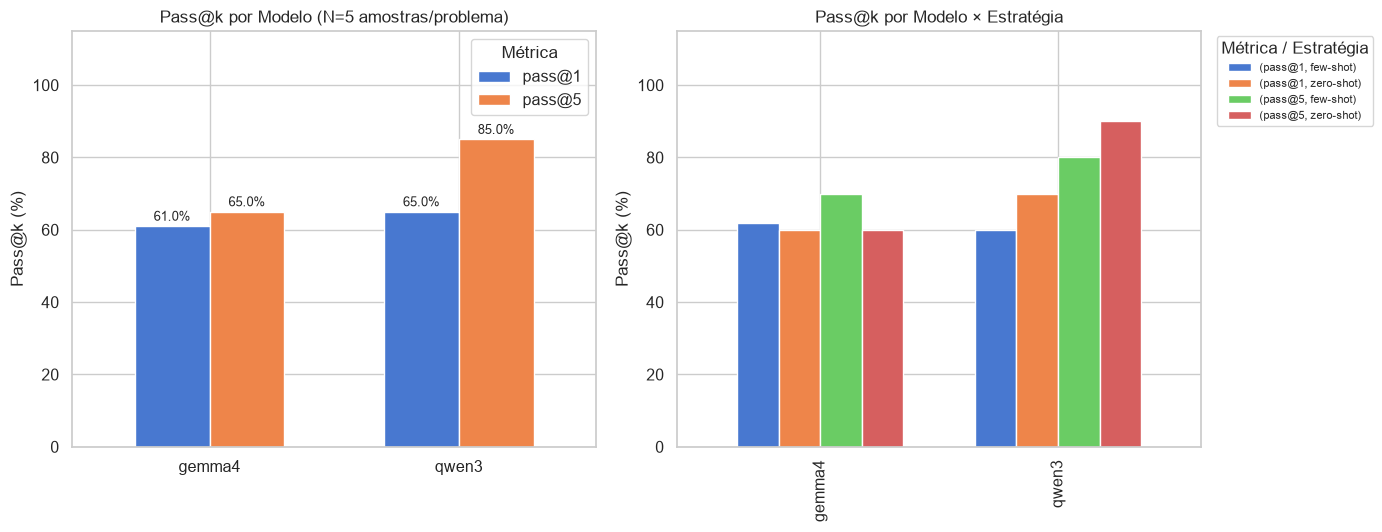

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

ax = axes[0]
resumo_pass_k_modelo.plot(kind="bar", ax=ax, edgecolor="white", width=0.6)
ax.set_ylabel("Pass@k (%)")
ax.set_title(f"Pass@k por Modelo (N={N_AMOSTRAS} amostras/problema)")
ax.set_xlabel("")
ax.set_xticklabels(resumo_pass_k_modelo.index, rotation=0)
ax.set_ylim(0, 115)
ax.legend(title="Métrica")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=2, fontsize=9)

ax = axes[1]
resumo_pass_k.unstack("estrategia").plot(kind="bar", ax=ax, edgecolor="white", width=0.7)
ax.set_ylabel("Pass@k (%)")
ax.set_title("Pass@k por Modelo × Estratégia")
ax.set_xlabel("")
ax.set_ylim(0, 115)
ax.legend(title="Métrica / Estratégia", fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.savefig(BASE_DIR / "pass_k_resultados.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Carregamento dos Resultados

Carrega `results.csv` para análise. Se o experimento ainda não foi rodado, esta célula avisa e interrompe a análise.


In [18]:
if not RESULTS_FILE.exists():
    raise FileNotFoundError(
        "results.csv não encontrado. Rode a célula 'rodar_experimento()' na seção 11 primeiro."
    )

df = pd.read_csv(RESULTS_FILE)
df["erro"] = df["erro"].astype(bool)

# Compatibilidade com results.csv gerados antes da classificação de erros
# (seção 9) existir: preenche as colunas novas com valores neutros em vez
# de quebrar as seções 13.1/13.2 abaixo.
for coluna in ("categoria_erro", "excecao_principal", "detalhe_erro"):
    if coluna not in df.columns:
        df[coluna] = None
if df["categoria_erro"].isna().any():
    sem_categoria = df["categoria_erro"].isna()
    df.loc[sem_categoria & (df["correcao_funcional"] == 100), "categoria_erro"] = "sucesso"
    df.loc[sem_categoria & (df["correcao_funcional"] < 100), "categoria_erro"] = "desconhecido"
    n_recuperado = sem_categoria.sum()
    if n_recuperado > 0:
        print(f"⚠️  {n_recuperado} linha(s) sem categoria_erro (results.csv de versão anterior). "
              f"Categoria inferida apenas por correção_funcional==100, sem detalhe de exceção.")

with open(RESULTS_JSON, "w", encoding="utf-8") as f:
    json.dump(df.to_dict(orient="records"), f, ensure_ascii=False, indent=2)

print(f"{len(df)} linhas carregadas.")
df.head(10)

40 linhas carregadas.


,problema_id,titulo,nivel,modelo,estrategia,testes_aprovados,total_testes,correcao_funcional,erro,categoria_erro,excecao_principal,detalhe_erro
0,P01,Calcular intervalo entre notas,basico,qwen3.6,zero-shot,8,8,100.00,False,sucesso,NaN,NaN
1,P02,Validar escala maior,basico,qwen3.6,zero-shot,7,7,100.00,False,sucesso,NaN,NaN
2,P03,Converter cifra para semitom,basico,qwen3.6,zero-shot,6,6,100.00,False,sucesso,NaN,NaN
3,P04,Classificar tríade,intermediario,qwen3.6,zero-shot,0,0,0.00,True,lexico_semantico,ImportError,Erro de coleta (módulo não importável)
4,P05,Gerar campo harmônico maior,intermediario,qwen3.6,zero-shot,0,0,0.00,True,sintatico,IndentationError,Erro de coleta (módulo não importável)
5,P06,Detectar inversão de acorde,intermediario,qwen3.6,zero-shot,0,0,0.00,True,sintatico,IndentationError,Erro de coleta (módulo não importável)
6,P07,Validar progressão harmônica,intermediario,qwen3.6,zero-shot,7,7,100.00,False,sucesso,NaN,NaN
7,P08,Classificar tétrade,avancado,qwen3.6,zero-shot,6,7,85.71,True,logico,AssertionError,Distribuição de exceções entre testes: {'Asser...
8,P09,Verificar condução de vozes,avancado,qwen3.6,zero-shot,6,6,100.00,False,sucesso,NaN,NaN
9,P10,Detectar modulação tonal,avancado,qwen3.6,zero-shot,6,6,100.00,False,sucesso,NaN,NaN


## 13. Estatísticas Descritivas

In [19]:
resumo_modelo = df.groupby("modelo")["correcao_funcional"].agg(["mean", "std", "min", "max"]).round(2)
print("Correção funcional média por modelo:")
display(resumo_modelo)

resumo_estrategia = df.groupby("estrategia")["correcao_funcional"].agg(["mean", "std"]).round(2)
print("\nCorreção funcional média por estratégia:")
display(resumo_estrategia)

resumo_nivel = df.groupby(["nivel", "modelo"])["correcao_funcional"].mean().round(2).unstack()
print("\nCorreção funcional média por nível de dificuldade × modelo:")
display(resumo_nivel)

Correção funcional média por modelo:


,mean,std,min,max
modelo,,,,
gemma4,64.98,45.0,0.0,100.0
qwen3.6,64.29,48.5,0.0,100.0



Correção funcional média por estratégia:


,mean,std
estrategia,,
few-shot,63.98,46.26
zero-shot,65.29,47.30



Correção funcional média por nível de dificuldade × modelo:


modelo,gemma4,qwen3.6
nivel,,
avancado,66.67,80.95
basico,100.00,100.00
intermediario,37.44,25.00


## 13.1. Natureza dos Erros

Além de medir QUANTO o código gerado falhou (correção funcional), analisamos POR QUE falhou. Cada geração foi classificada em uma das categorias abaixo, a partir do tipo de exceção Python que apareceu na saída real do `pytest`:

| Categoria | Significado |
|---|---|
| `sucesso` | Passou em 100% dos testes |
| `sintatico` | Código nem é Python válido (`SyntaxError`, `IndentationError`) |
| `lexico_semantico` | Sintaxe válida, mas referencia nomes/atributos inexistentes (`NameError`, `ImportError`, `AttributeError`) |
| `runtime` | Código executa mas lança exceção durante um teste (`TypeError`, `ValueError`, `IndexError`, `KeyError`...) |
| `logico` | Código executa sem erro, mas o resultado está errado (`AssertionError`) |
| `timeout` | Excedeu o tempo limite de execução |
| `geracao_vazia` | O modelo não retornou código algum |

Essa distinção é importante: um erro **sintático** indica que o modelo nem domina a gramática da linguagem para aquele caso, enquanto um erro **lógico** indica que o modelo entende Python mas falha no raciocínio sobre teoria musical — são falhas qualitativamente diferentes para a discussão do artigo.


In [20]:
print("Distribuição de categorias de erro por modelo:")
distrib_categoria = pd.crosstab(df["modelo"], df["categoria_erro"], normalize="index").mul(100).round(1)
display(distrib_categoria)

print("\nDistribuição de categorias de erro por modelo × estratégia:")
distrib_categoria_estrategia = pd.crosstab(
    [df["modelo"], df["estrategia"]], df["categoria_erro"], normalize="index"
).mul(100).round(1)
display(distrib_categoria_estrategia)

print("\nExceções específicas mais comuns (top 10), por modelo:")
excecoes_validas = df[df["excecao_principal"].notna()]
if len(excecoes_validas) > 0:
    top_excecoes = (
        excecoes_validas.groupby(["modelo", "excecao_principal"])
        .size()
        .sort_values(ascending=False)
        .groupby(level=0, group_keys=False)
        .head(10)
    )
    display(top_excecoes)
else:
    print("  (nenhuma exceção registrada — todos os casos foram sucesso ou sem padrão identificado)")

print("\nDistribuição de categoria de erro por nível de dificuldade:")
distrib_nivel = pd.crosstab(df["nivel"], df["categoria_erro"], normalize="index").mul(100).round(1)
display(distrib_nivel)

Distribuição de categorias de erro por modelo:


categoria_erro,lexico_semantico,logico,sintatico,sucesso
modelo,,,,
gemma4,0.0,25.0,15.0,60.0
qwen3.6,5.0,5.0,30.0,60.0



Distribuição de categorias de erro por modelo × estratégia:


categoria_erro      lexico_semantico  logico  sintatico  sucesso
modelo  estrategia                                              
gemma4  few-shot                 0.0    30.0       10.0     60.0
        zero-shot                0.0    20.0       20.0     60.0
qwen3.6 few-shot                 0.0     0.0       40.0     60.0
        zero-shot               10.0    10.0       20.0     60.0


Exceções específicas mais comuns (top 10), por modelo:


modelo   excecao_principal
gemma4   AssertionError       5
qwen3.6  IndentationError     5
gemma4   SyntaxError          3
qwen3.6  AssertionError       1
         ImportError          1
         SyntaxError          1
dtype: int64


Distribuição de categoria de erro por nível de dificuldade:


categoria_erro,lexico_semantico,logico,sintatico,sucesso
nivel,,,,
avancado,0.0,8.3,25.0,66.7
basico,0.0,0.0,0.0,100.0
intermediario,6.2,31.2,37.5,25.0


### 13.2. Visualização: Natureza dos Erros

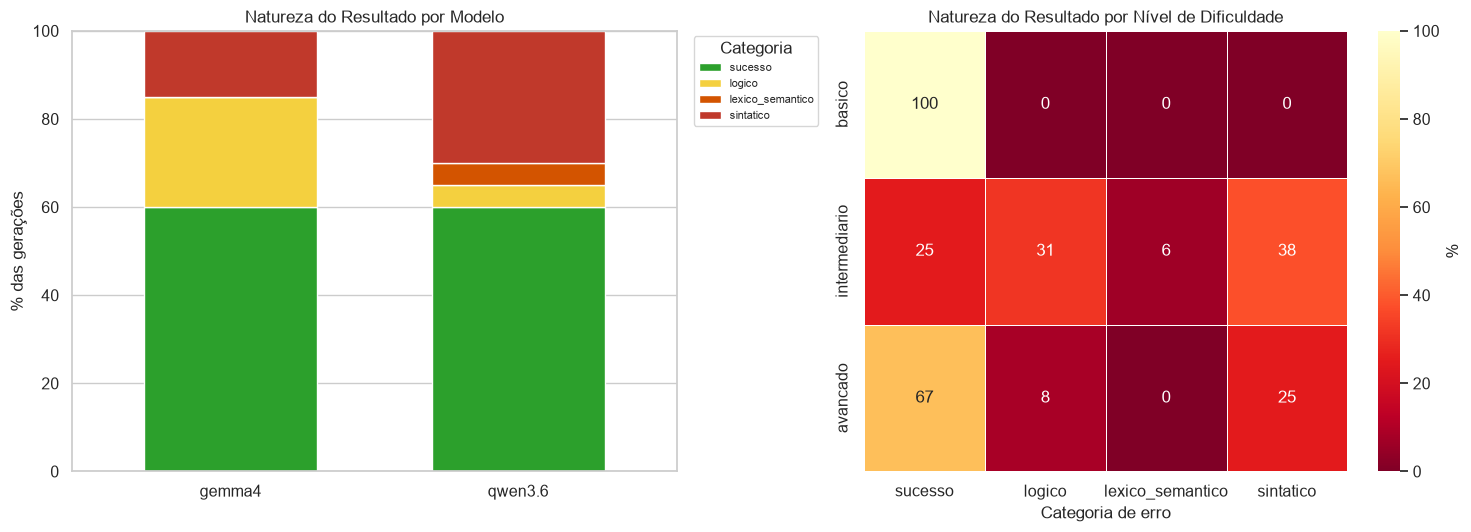

In [21]:
categorias_ordenadas = ["sucesso", "logico", "runtime", "lexico_semantico",
                        "sintatico", "timeout", "geracao_vazia", "desconhecido"]
cores_categoria = {
    "sucesso": "#2ca02c", "logico": "#f4d03f", "runtime": "#e67e22",
    "lexico_semantico": "#d35400", "sintatico": "#c0392b",
    "timeout": "#7f8c8d", "geracao_vazia": "#95a5a6", "desconhecido": "#34495e",
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# 1. Barras 100% empilhadas: distribuição de categoria de erro por modelo
ax = axes[0]
contagem_cat = pd.crosstab(df["modelo"], df["categoria_erro"], normalize="index").mul(100)
colunas_presentes = [c for c in categorias_ordenadas if c in contagem_cat.columns]
contagem_cat = contagem_cat[colunas_presentes]
contagem_cat.plot(kind="bar", stacked=True, ax=ax, edgecolor="white",
                   color=[cores_categoria.get(c, "#333333") for c in colunas_presentes], width=0.6)
ax.set_ylabel("% das gerações")
ax.set_title("Natureza do Resultado por Modelo")
ax.set_xlabel("")
ax.set_xticklabels(contagem_cat.index, rotation=0)
ax.legend(title="Categoria", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set_ylim(0, 100)

# 2. Heatmap: categoria de erro por nível de dificuldade
ax = axes[1]
pivot_nivel_cat = pd.crosstab(df["nivel"], df["categoria_erro"], normalize="index").mul(100)
colunas_presentes2 = [c for c in categorias_ordenadas if c in pivot_nivel_cat.columns]
pivot_nivel_cat = pivot_nivel_cat[colunas_presentes2]
ordem_nivel_idx = [n for n in ["basico", "intermediario", "avancado"] if n in pivot_nivel_cat.index]
pivot_nivel_cat = pivot_nivel_cat.loc[ordem_nivel_idx]
sns.heatmap(pivot_nivel_cat, ax=ax, annot=True, fmt=".0f", cmap="YlOrRd_r",
            linewidths=0.5, linecolor="white", cbar_kws={"label": "%"})
ax.set_title("Natureza do Resultado por Nível de Dificuldade")
ax.set_xlabel("Categoria de erro")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(BASE_DIR / "natureza_erros.png", dpi=150, bbox_inches="tight")
plt.show()

## 14. Análise Estatística — Teste de Wilcoxon

Compara os modelos (e as estratégias) de forma pareada por problema, usando o teste de Wilcoxon signed-rank — não-paramétrico, adequado para o N pequeno deste experimento (10 problemas por condição).


In [22]:
def comparar_modelos_wilcoxon(df, modelo_a, modelo_b, estrategia=None):
    sub = df if estrategia is None else df[df["estrategia"] == estrategia]

    pivot = sub.pivot_table(
        values="correcao_funcional", index="problema_id", columns="modelo", aggfunc="mean"
    )

    if modelo_a not in pivot.columns or modelo_b not in pivot.columns:
        print(f"  Dados insuficientes para comparar {modelo_a} vs {modelo_b}.")
        return None

    pares = pivot[[modelo_a, modelo_b]].dropna()
    if len(pares) < 2 or (pares[modelo_a] == pares[modelo_b]).all():
        print(f"  Sem variação suficiente para Wilcoxon ({modelo_a} vs {modelo_b}).")
        return None

    estatistica, p_valor = stats.wilcoxon(pares[modelo_a], pares[modelo_b])
    contexto = f" (estratégia={estrategia})" if estrategia else ""
    print(f"  Wilcoxon {modelo_a} vs {modelo_b}{contexto}: estatística={estatistica:.3f}, p={p_valor:.4f}")
    return estatistica, p_valor


modelos_unicos = df["modelo"].unique().tolist()
print("Comparação geral (todas as estratégias agregadas):")
if len(modelos_unicos) >= 2:
    comparar_modelos_wilcoxon(df, modelos_unicos[0], modelos_unicos[1])

print("\nComparação por estratégia:")
for estrategia in STRATEGIES:
    if len(modelos_unicos) >= 2:
        comparar_modelos_wilcoxon(df, modelos_unicos[0], modelos_unicos[1], estrategia=estrategia)

print("\nComparação zero-shot vs few-shot (mesmo modelo):")
for modelo in modelos_unicos:
    sub = df[df["modelo"] == modelo]
    pivot = sub.pivot_table(values="correcao_funcional", index="problema_id", columns="estrategia", aggfunc="mean")
    if "zero-shot" in pivot.columns and "few-shot" in pivot.columns:
        pares = pivot[["zero-shot", "few-shot"]].dropna()
        if len(pares) >= 2 and not (pares["zero-shot"] == pares["few-shot"]).all():
            estatistica, p_valor = stats.wilcoxon(pares["zero-shot"], pares["few-shot"])
            print(f"  {modelo}: zero-shot vs few-shot — estatística={estatistica:.3f}, p={p_valor:.4f}")
        else:
            print(f"  {modelo}: dados insuficientes para Wilcoxon.")

Comparação geral (todas as estratégias agregadas):
  Wilcoxon qwen3.6 vs gemma4: estatística=4.000, p=0.8750

Comparação por estratégia:
  Wilcoxon qwen3.6 vs gemma4 (estratégia=zero-shot): estatística=1.000, p=1.0000
  Wilcoxon qwen3.6 vs gemma4 (estratégia=few-shot): estatística=0.000, p=0.2500

Comparação zero-shot vs few-shot (mesmo modelo):
  qwen3.6: zero-shot vs few-shot — estatística=0.000, p=1.0000
  gemma4: zero-shot vs few-shot — estatística=0.000, p=0.5000


In [23]:
# Correlação entre nível de dificuldade (ordinal) e correção funcional
mapa_nivel = {"basico": 1, "intermediario": 2, "avancado": 3}
df["nivel_num"] = df["nivel"].map(mapa_nivel)

corr, p_corr = stats.pearsonr(df["nivel_num"], df["correcao_funcional"])
print(f"Correlação Pearson entre dificuldade e correção funcional: r={corr:.3f}, p={p_corr:.4f}")

Correlação Pearson entre dificuldade e correção funcional: r=-0.222, p=0.1677


## 15. Visualizações

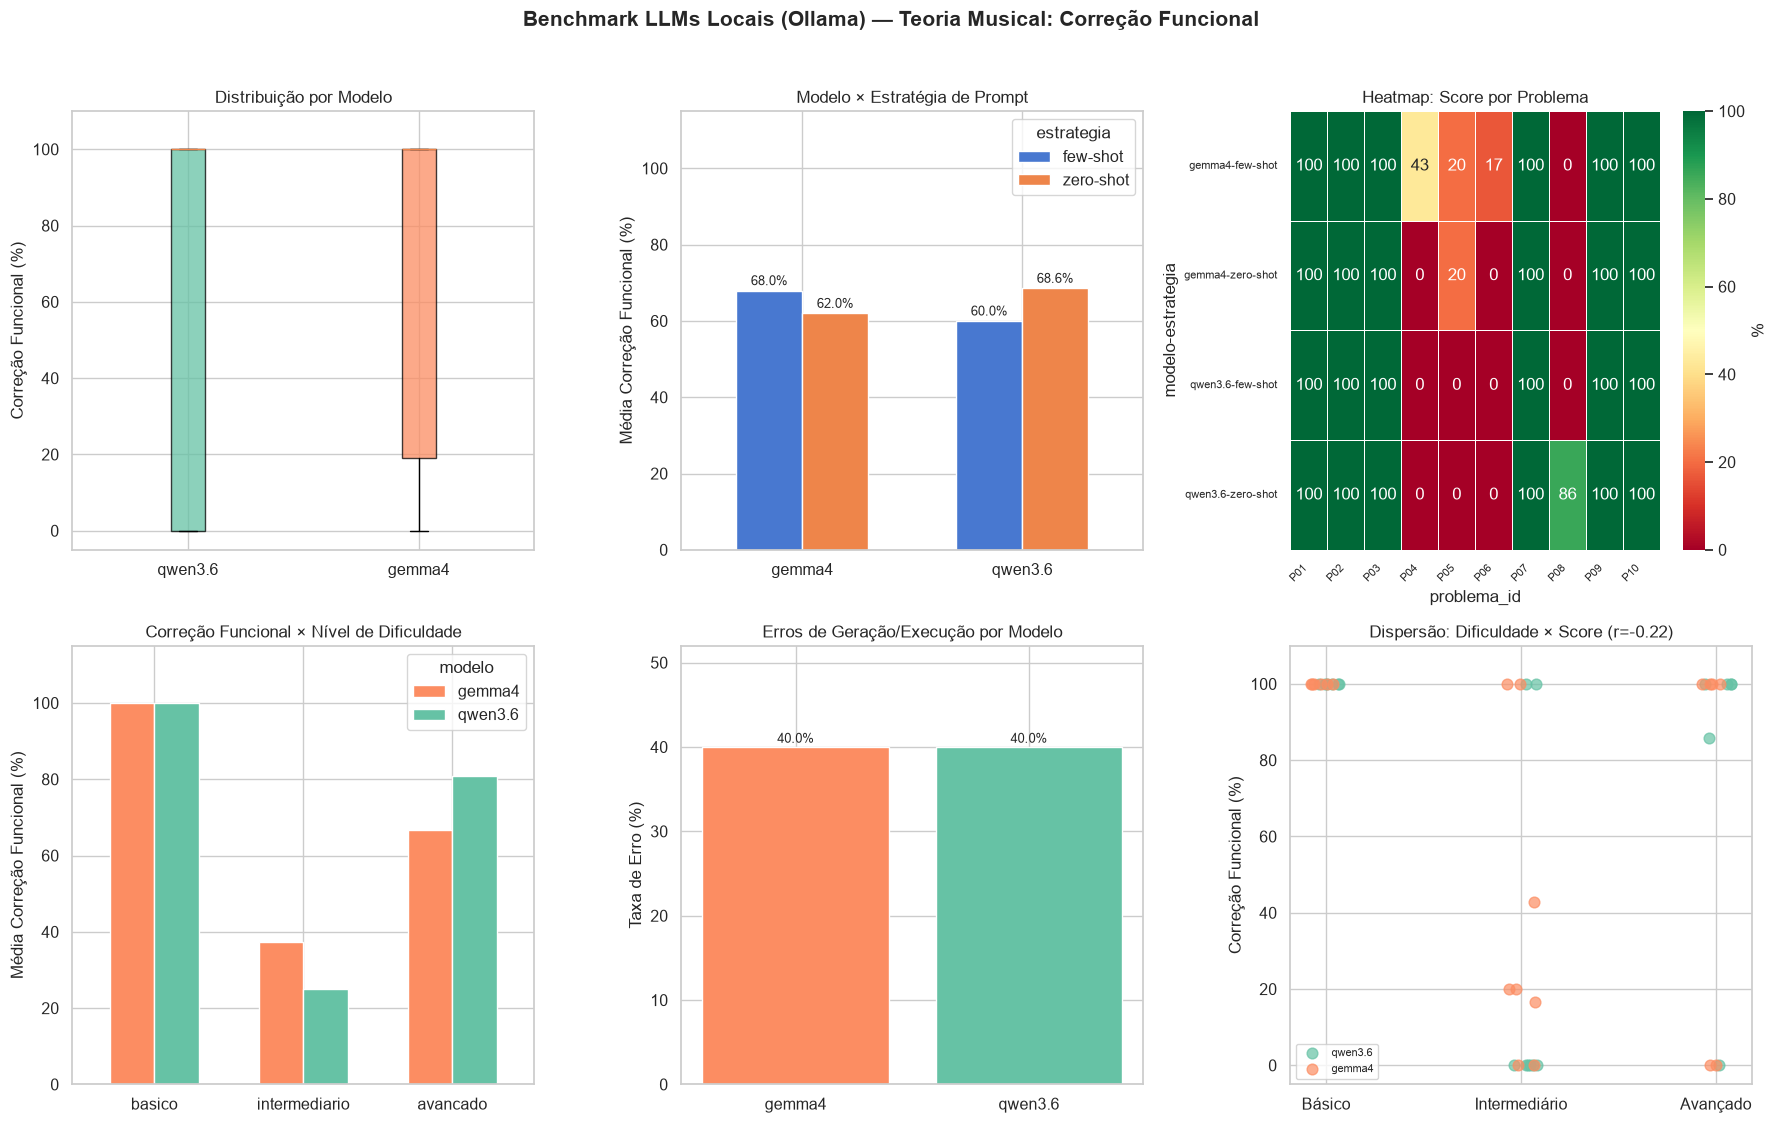

In [24]:
paleta = sns.color_palette("Set2", n_colors=max(len(modelos_unicos), 2))
cor_modelo = {m: paleta[i] for i, m in enumerate(modelos_unicos)}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Benchmark LLMs Locais (Ollama) — Teoria Musical: Correção Funcional",
             fontsize=15, fontweight="bold", y=1.02)

# 1. Boxplot por modelo
ax = axes[0, 0]
data_box = [df[df["modelo"] == m]["correcao_funcional"].values for m in modelos_unicos]
try:
    # Matplotlib >= 3.9 renomeou o parâmetro para tick_labels
    bp = ax.boxplot(data_box, tick_labels=modelos_unicos, patch_artist=True, notch=False)
except TypeError:
    # Compatibilidade com versões mais antigas do matplotlib (< 3.9)
    bp = ax.boxplot(data_box, labels=modelos_unicos, patch_artist=True, notch=False)
for patch, modelo in zip(bp["boxes"], modelos_unicos):
    patch.set_facecolor(cor_modelo[modelo])
    patch.set_alpha(0.75)
ax.set_ylabel("Correção Funcional (%)")
ax.set_title("Distribuição por Modelo")
ax.set_ylim(-5, 110)

# 2. Barras Modelo x Estratégia
ax = axes[0, 1]
pivot_ms = df.pivot_table(values="correcao_funcional", index="modelo", columns="estrategia", aggfunc="mean")
pivot_ms.plot(kind="bar", ax=ax, edgecolor="white", width=0.6)
ax.set_xlabel("")
ax.set_ylabel("Média Correção Funcional (%)")
ax.set_title("Modelo × Estratégia de Prompt")
ax.set_xticklabels(pivot_ms.index, rotation=0)
ax.set_ylim(0, 115)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=2, fontsize=9)

# 3. Heatmap por problema
ax = axes[0, 2]
pivot_prob = df.pivot_table(values="correcao_funcional", index=["modelo", "estrategia"], columns="problema_id", aggfunc="mean")
sns.heatmap(pivot_prob, ax=ax, annot=True, fmt=".0f", cmap="RdYlGn",
            linewidths=0.5, linecolor="white", vmin=0, vmax=100, cbar_kws={"label": "%"})
ax.set_title("Heatmap: Score por Problema")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# 4. Correção funcional por nível de dificuldade
ax = axes[1, 0]
pivot_nivel = df.pivot_table(values="correcao_funcional", index="nivel", columns="modelo", aggfunc="mean")
ordem_nivel = [n for n in ["basico", "intermediario", "avancado"] if n in pivot_nivel.index]
pivot_nivel = pivot_nivel.loc[ordem_nivel]
pivot_nivel.plot(kind="bar", ax=ax, edgecolor="white", width=0.6,
                  color=[cor_modelo[m] for m in pivot_nivel.columns])
ax.set_xlabel("")
ax.set_ylabel("Média Correção Funcional (%)")
ax.set_title("Correção Funcional × Nível de Dificuldade")
ax.set_xticklabels(ordem_nivel, rotation=0)
ax.set_ylim(0, 115)

# 5. Taxa de erro (geração) por modelo
ax = axes[1, 1]
taxa_erro = df.groupby("modelo")["erro"].mean().mul(100).round(1)
ax.bar(taxa_erro.index, taxa_erro.values, color=[cor_modelo[m] for m in taxa_erro.index], edgecolor="white")
ax.set_ylabel("Taxa de Erro (%)")
ax.set_title("Erros de Geração/Execução por Modelo")
ax.set_ylim(0, max(10, taxa_erro.max() * 1.3 if len(taxa_erro) else 10))
for i, v in enumerate(taxa_erro.values):
    ax.text(i, v + 0.5, f"{v}%", ha="center", fontsize=9)

# 6. Dispersão dificuldade x correção
ax = axes[1, 2]
for modelo in modelos_unicos:
    sub = df[df["modelo"] == modelo]
    ax.scatter(sub["nivel_num"] + np.random.uniform(-0.08, 0.08, len(sub)),
               sub["correcao_funcional"], label=modelo, alpha=0.7, color=cor_modelo[modelo], s=60)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(["Básico", "Intermediário", "Avançado"])
ax.set_ylabel("Correção Funcional (%)")
ax.set_title(f"Dispersão: Dificuldade × Score (r={corr:.2f})")
ax.legend(fontsize=8)
ax.set_ylim(-5, 110)

plt.tight_layout()
plt.savefig(BASE_DIR / "benchmark_resultados.png", dpi=150, bbox_inches="tight")
plt.show()

## 16. Exportação Final

Exporta um resumo consolidado em JSON e CSV para uso no artigo/relatório.


In [25]:
resumo_final = {
    "modelos_avaliados": modelos_unicos,
    "estrategias_avaliadas": STRATEGIES,
    "total_geracoes": len(df),
    "correcao_media_geral": round(df["correcao_funcional"].mean(), 2),
    "correcao_por_modelo": df.groupby("modelo")["correcao_funcional"].mean().round(2).to_dict(),
    "correcao_por_estrategia": df.groupby("estrategia")["correcao_funcional"].mean().round(2).to_dict(),
    "correcao_por_nivel": df.groupby("nivel")["correcao_funcional"].mean().round(2).to_dict(),
    "taxa_erro_por_modelo": df.groupby("modelo")["erro"].mean().mul(100).round(2).to_dict(),
    "distribuicao_categoria_erro_por_modelo": {
        modelo: df[df["modelo"] == modelo]["categoria_erro"].value_counts().to_dict()
        for modelo in modelos_unicos
    },
    "excecoes_mais_comuns_por_modelo": {
        modelo: df[(df["modelo"] == modelo) & (df["excecao_principal"].notna())]
                ["excecao_principal"].value_counts().head(5).to_dict()
        for modelo in modelos_unicos
    },
}

with open(BASE_DIR / "resumo_experimento.json", "w", encoding="utf-8") as f:
    json.dump(resumo_final, f, ensure_ascii=False, indent=2)

print(json.dumps(resumo_final, ensure_ascii=False, indent=2))

{
  "modelos_avaliados": [
    "qwen3.6",
    "gemma4"
  ],
  "estrategias_avaliadas": [
    "zero-shot",
    "few-shot"
  ],
  "total_geracoes": 40,
  "correcao_media_geral": 64.63,
  "correcao_por_modelo": {
    "gemma4": 64.98,
    "qwen3.6": 64.29
  },
  "correcao_por_estrategia": {
    "few-shot": 63.98,
    "zero-shot": 65.29
  },
  "correcao_por_nivel": {
    "avancado": 73.81,
    "basico": 100.0,
    "intermediario": 31.22
  },
  "taxa_erro_por_modelo": {
    "gemma4": 40.0,
    "qwen3.6": 40.0
  },
  "distribuicao_categoria_erro_por_modelo": {
    "qwen3.6": {
      "sucesso": 12,
      "sintatico": 6,
      "lexico_semantico": 1,
      "logico": 1
    },
    "gemma4": {
      "sucesso": 12,
      "logico": 5,
      "sintatico": 3
    }
  },
  "excecoes_mais_comuns_por_modelo": {
    "qwen3.6": {
      "IndentationError": 5,
      "ImportError": 1,
      "AssertionError": 1,
      "SyntaxError": 1
    },
    "gemma4": {
      "AssertionError": 5,
      "SyntaxError": 3
    }
